# StudyBuild_ML_Project01: Credit Default Risk

## Importing Recuired Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\\Academic Folders\\StudyBuild\\Machine Learning Team\\Project 01\\File\\default of credit card clients.csv")

In [3]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


## The overall structure of Dataset:
### - Basic Information: LIMIT_BAL, SEX, EDUCATION, AGE
##### LIMIT_BAL : This is the customer's assigned credit limit( How much credit has the company made available to this customer?)
##### Education : 1 = graduate school, 2 = university, 3 = high school, 4 = others
##### Marriage: 1 = Married, 2 = Single, 3 = Others
### - Repayment history: PAY_0, ..., PAY_6
##### This is the repayment status history. The six variables represent the customer's repayment status over six previous months.
##### PAY_0 represents the most recent repayment-status observation and PAY_6 is the oldest.
##### The value represents how many months the payment was delayed. -2: account started that month/no consumption, -1: paid duly, 0: no payment delay, 1: payment delayed 1 month, 2: payment delayed 2 months and ...
### - Bill statements: BILL_AMT1, ..., BILL_AMT6
##### It means bill statements, BILL_AMT = How much was billed?
### - Previous payments: PAY_AMT1, ..., PAY_AMT6
##### It means how much did the customer actually pay?
### - Target: default.payment.next.month
##### Did this customer default on their next payment? 0: did not default, 1: defaulted

#### We have a dataset-loading issue, the UCI file has an extra header, so pandas may have interpreted as the column names, while the next row contains the real names!

In [4]:
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

##### df.columns = df.iloc[0] means take the first row and make its values the column names.

##### Oops another problem!
##### We changed the first row into column names and removed it, but because the data was initially loaded in a way that caused the columns to be interpreted as objects, pandas may have kept the values as strings.

In [5]:
df.dtypes

0
ID                            str
LIMIT_BAL                     str
SEX                           str
EDUCATION                     str
MARRIAGE                      str
AGE                           str
PAY_0                         str
PAY_2                         str
PAY_3                         str
PAY_4                         str
PAY_5                         str
PAY_6                         str
BILL_AMT1                     str
BILL_AMT2                     str
BILL_AMT3                     str
BILL_AMT4                     str
BILL_AMT5                     str
BILL_AMT6                     str
PAY_AMT1                      str
PAY_AMT2                      str
PAY_AMT3                      str
PAY_AMT4                      str
PAY_AMT5                      str
PAY_AMT6                      str
default payment next month    str
dtype: object

##### Converting every column into a number

In [6]:
df = df.apply(pd.to_numeric, errors="coerce")

##### errors="coerce" means if something cannot be converted into a number, turn it into NaN rather than crashing

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Q1 - What does the portfolio look like before modeling?

##### Number of clients:

In [8]:
df.shape

(30000, 25)

In [9]:
df.isnull().sum()

0
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

##### isnull().sum() shows how many missing values are there in each column, which as we can see there is none

In [10]:
df.duplicated().sum()

np.int64(0)

##### There are no completely identical customer records.

In [11]:
df["SEX"].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [12]:
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})
df["EDUCATION"].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

##### 0, 5, 6 are unusual encoding so we merged them into column 4

In [13]:
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

##### 1 (Married) : 13,659
##### 2 (Single) : 15,964
##### 3 (Others) : 323
##### 0 : 54 unusual/unknown so this column is merged into column 3 (Others)

In [14]:
df["default payment next month"].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

##### 0 = No default and 1 = Default
##### So there are:
##### 23364 non-defaulters and 6636 defaulters
##### calculating the percentages:
##### No default : 77.88%
##### Default    : 22.12%
##### So approximately:
##### 77.88% did not default and 22.12% did default (one in every five customers defaulted in the observed next-payment period).

#### Credit-limit distribution: LIMIT_BAL

In [15]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

##### Mean = 167484 but Median = 140000
##### The mean is noticeably higher than the median. This suggests the distribution is right-skewed: some customers have substantially higher credit limits and pull the average upward.
##### The range is also large:
##### 10000(min) - 1000000(max)
##### So the portfolio contains customers with very different levels of available credit.
##### And the standard deviation: 129748 is quite large relative to the mean, confirming that credit limits vary substantially across customers.

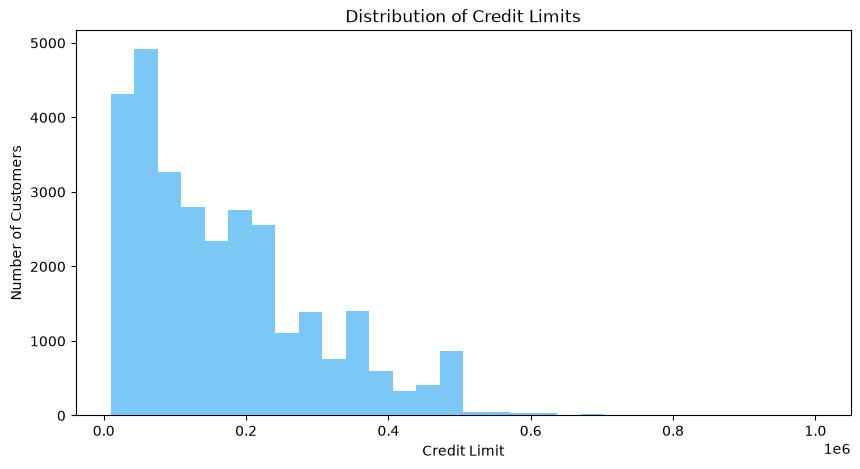

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["LIMIT_BAL"], bins=30, color="#7BC8F6")

plt.title("Distribution of Credit Limits")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

#### Age Profile

In [17]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

##### The portfolio has an average client age of approximately 35.5 years, with a median of 34 years. The middle 50% of clients are between 28 and 41 years old which means most of the customers are concentrated around young-to-middle adulthood, while the observed range is 21 to 79 years. The mean being slightly above the median suggests a mild right-skew caused by a smaller number of older clients. No obviously implausible ages are apparent from the summary statistics such as age 0, 5, or 150.

In [18]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
for col in pay_cols:
    print(df[col].value_counts().sort_index())

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64


##### There are more customers in the 0 category in the older months than in the most recent month.
##### As the delay becomes longer, the number of customers drops dramatically.

In [19]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]
df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


##### The average bill decreases over the six observations.
##### The median is much lower than the mean, this strongly suggests that the bill amounts are right-skewed which means most customers have relatively modest bill amounts, while a smaller number of customers have very large bills, which pull the mean upward.
##### BILL_AMT3 reaches 1,664,089, which is considerably larger than the maximum in most other months.
##### Negative statement amounts can occur in financial data because of things such as credits, adjustments, refunds, overpayments, or other account-level accounting effects.
##### The middle 50% is much smaller than the full range which means the majority of customers are nowhere near the maximum. A relatively small number of very large observations create a huge upper tail.


In [20]:
pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

df[pay_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
PAY_AMT4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
PAY_AMT5,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
PAY_AMT6,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


##### Most customers make relatively small payments.
##### The mean is substantially higher than the median in every month. This suggests the payment distributions are strongly right-skewed.
##### In other words: Most customers make relatively modest payments, while a smaller number make very large payments.
##### There are customers with zero payments (All six variables have: min = 0), that means some customers made no recorded payment in the corresponding month. PAY_AMT = 0 does not automatically mean the customer defaulted.
##### The maximum values are enormous compared with the median (PAY_AMT2: median = 2,009 and maximum = 1,684,259), it means the payment distribution has a very long upper tail.
##### Payment amounts appear lower in older observations

#### Comparing BILL_AMT and PAY_AMT:
##### The typical recorded payment amount is substantially smaller than the typical statement amount.

### Default vs Non-default

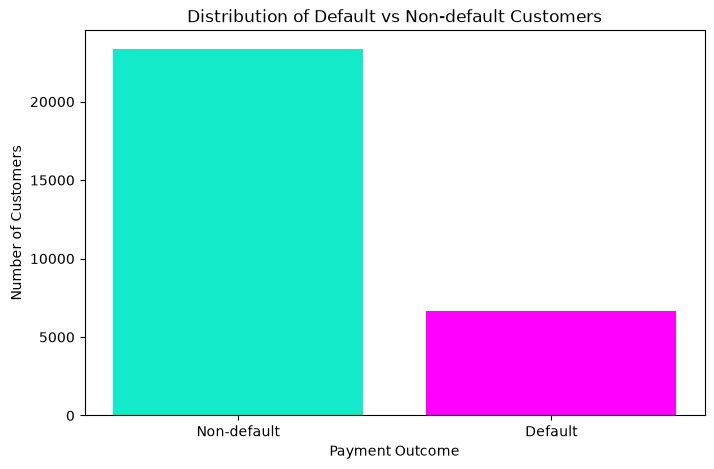

In [21]:
target_counts = df["default payment next month"].value_counts().sort_index()

labels = ["Non-default", "Default"]

plt.figure(figsize=(8, 5))

plt.bar(labels, target_counts.values, color=["#13EAC9","#FF00FF"])

plt.title("Distribution of Default vs Non-default Customers")
plt.xlabel("Payment Outcome")
plt.ylabel("Number of Customers")

plt.show()

##### The dataset contains 30,000 customers, of whom 23,364 (77.88%) did not default and 6,636 (22.12%) defaulted. The target is therefore moderately imbalanced. A model predicting every customer as non-default would achieve approximately 77.9% accuracy while completely failing to identify defaulters. Therefore, accuracy alone is insufficient for evaluating the classification model, and metrics such as Recall, Precision, F1-score, ROC-AUC and PR-AUC will be considered.

### Age distribution

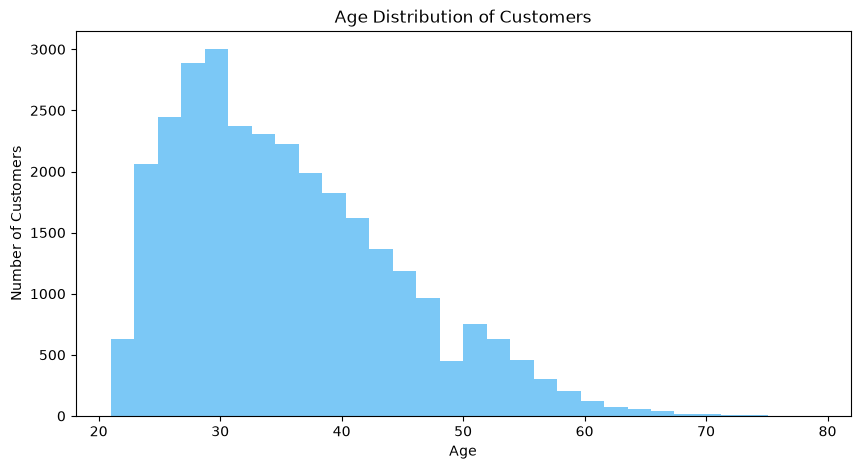

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(df["AGE"], bins=30, color="#7BC8F6")

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Repayment-status distributions

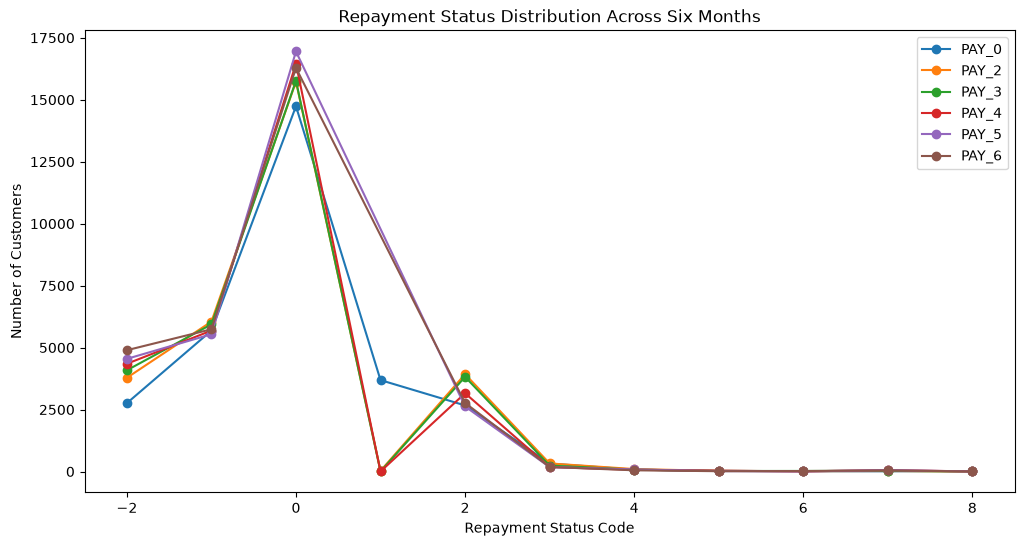

In [23]:
pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

plt.figure(figsize=(12, 6))

for col in pay_cols:
    counts = df[col].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker="o", label=col)

plt.title("Repayment Status Distribution Across Six Months")
plt.xlabel("Repayment Status Code")
plt.ylabel("Number of Customers")

plt.legend()

plt.show()

##### Across all six repayment-status variables, the majority of customers fall into the non-positive status categories (-2, -1, and 0). Positive delay codes are substantially less frequent, and their frequency generally decreases as the recorded delay becomes more severe. The most recent repayment-status variable, PAY_0, contains a relatively large number of one- and two-month delay observations compared with the more severe categories. The negative and zero codes are valid dataset-specific categories rather than missing values and should therefore be preserved and documented during preprocessing.

### Bill amounts

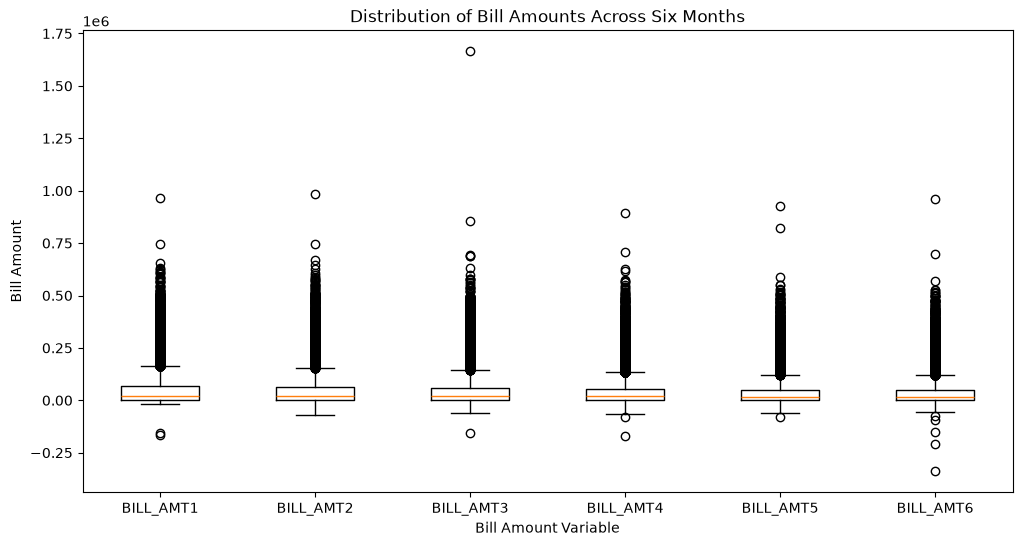

In [24]:
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    [df[col] for col in bill_cols],
    tick_labels=bill_cols
)

plt.title("Distribution of Bill Amounts Across Six Months")
plt.xlabel("Bill Amount Variable")
plt.ylabel("Bill Amount")

plt.show()

##### Payment amounts are strongly right-skewed across all six observations. Median payment amounts range from approximately 1,500 to 2,100, while the means are substantially higher because of a relatively small number of very large payments. Zero-payment observations are present in every month. The extreme upper-tail values should be investigated as part of data-quality analysis but should not automatically be treated as errors.

### Default rate by repayment status
#### Among customers with each repayment status, what percentage defaulted?

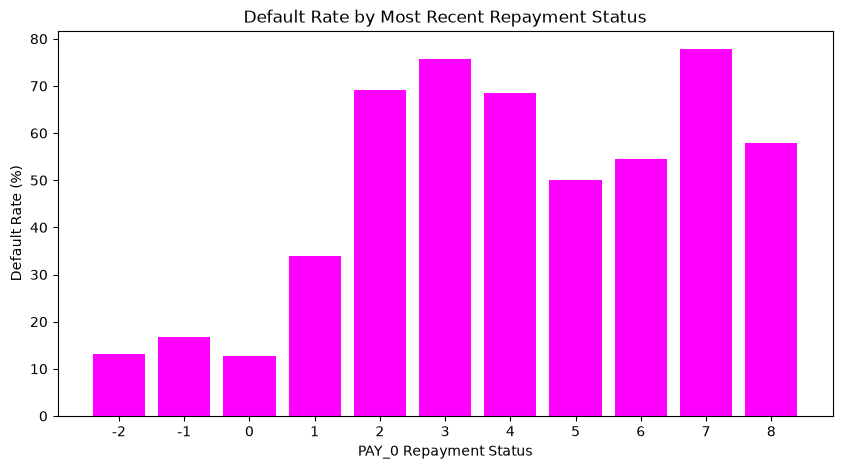

In [25]:
default_rate_pay0 = (
    df.groupby("PAY_0")["default payment next month"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    default_rate_pay0["PAY_0"].astype(str),
    default_rate_pay0["default payment next month"] * 100,
    color="#FF00FF"
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0 Repayment Status")
plt.ylabel("Default Rate (%)")

plt.show()

### Default rate across all six repayment histories
##### calculating the default rate for every repayment status across all six months and creating a heatmap

In [26]:
pay_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

default_rates = pd.DataFrame()

for col in pay_cols:
    rates = df.groupby(col)["default payment next month"].mean()
    default_rates[col] = rates

default_rates = default_rates * 100

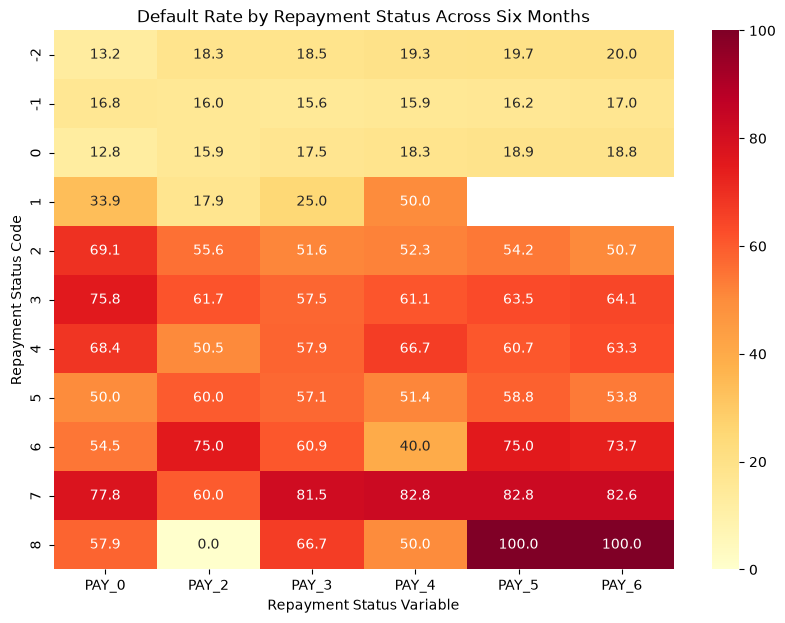

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    default_rates,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Default Rate by Repayment Status Across Six Months")
plt.xlabel("Repayment Status Variable")
plt.ylabel("Repayment Status Code")

plt.show()

### Q1 Explanation
##### The dataset contains 30,000 customer records and includes demographic information, credit limit, repayment status, bill amounts, payment amounts, and the target variable indicating whether the customer defaulted on the next payment.

##### The target variable, default payment next month, is binary: 0 represents non-default and 1 represents default. There are 23,364 non-default customers (77.88%) and 6,636 default customers (22.12%).

##### The dataset therefore has a noticeable class imbalance, with non-default customers representing the majority of observations. This is important for model evaluation because a model can achieve relatively high Accuracy by favoring the majority class while still performing poorly at identifying actual defaulters.

##### The dataset also contains categorical variables such as SEX, EDUCATION, and MARRIAGE, as well as numerical variables such as LIMIT_BAL, AGE, bill amounts, payment amounts, and repayment-status variables. Some variables contain dataset-specific codes or unusual values, which were documented and handled during preprocessing.

# Q2 - Which customer characteristics differ between default and non-default groups?

In [28]:
non_default = df[df["default payment next month"] == 0]
default = df[df["default payment next month"] == 1]

print("Non-default customers:", len(non_default))
print("Default customers:", len(default))

Non-default customers: 23364
Default customers: 6636


### Age vs default rate

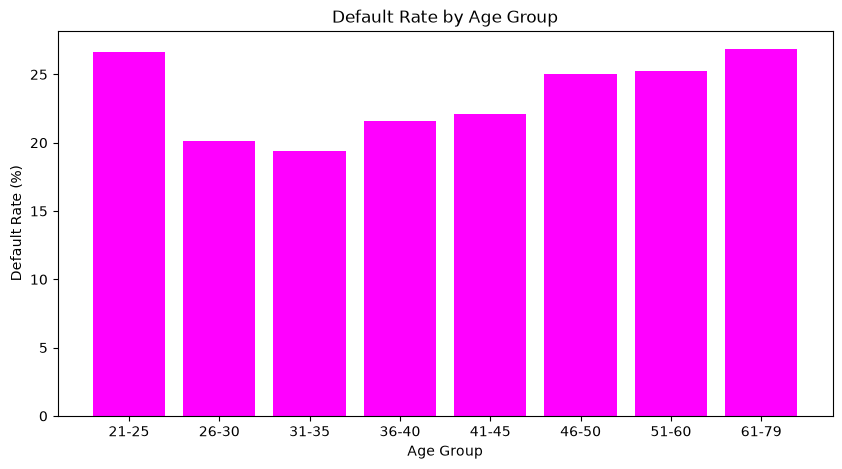

In [29]:
bins = [20, 25, 30, 35, 40, 45, 50, 60, 80]
labels = [
    "21-25", "26-30", "31-35", "36-40",
    "41-45", "46-50", "51-60", "61-79"
]

df["age_group"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_default = (
    df.groupby("age_group", observed=True)["default payment next month"]
      .mean() * 100
)

plt.figure(figsize=(10, 5))

plt.bar(age_default.index.astype(str), age_default.values, color="#FF00FF")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [30]:
pay_default = df.groupby(
    "default payment next month"
)[pay_amt_cols].median().T

print(pay_default)

default payment next month       0       1
0                                         
PAY_AMT1                    2459.5  1636.0
PAY_AMT2                    2247.5  1533.5
PAY_AMT3                    2000.0  1222.0
PAY_AMT4                    1734.0  1000.0
PAY_AMT5                    1765.0  1000.0
PAY_AMT6                    1706.0  1000.0


### Payment amount vs default status

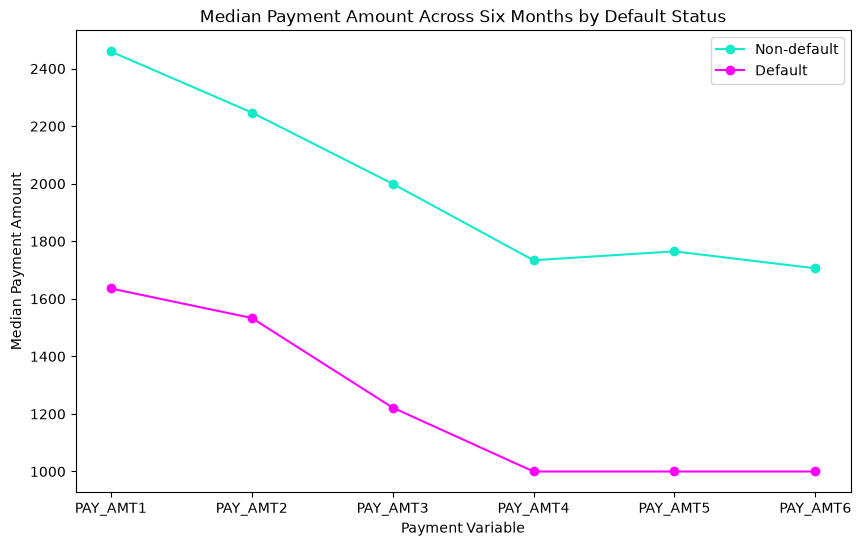

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    pay_default.index,
    pay_default[0],
    marker="o",
    label="Non-default",
    color="#13EAC9"
)

plt.plot(
    pay_default.index,
    pay_default[1],
    marker="o",
    label="Default",
    color="#FF00FF"
)

plt.title("Median Payment Amount Across Six Months by Default Status")
plt.xlabel("Payment Variable")
plt.ylabel("Median Payment Amount")

plt.legend()

plt.show()

### For each repayment status, what percentage defaulted and what percentage didn't?

In [32]:
pd.crosstab(
    df["PAY_0"],
    df["default payment next month"],
    normalize="index"
) * 100

default payment next month,0,1
PAY_0,,
-2,86.770569,13.229431
-1,83.221949,16.778051
0,87.188709,12.811291
1,66.052061,33.947939
2,30.858643,69.141357
3,24.223602,75.776398
4,31.578947,68.421053
5,50.000000,50.000000
6,45.454545,54.545455


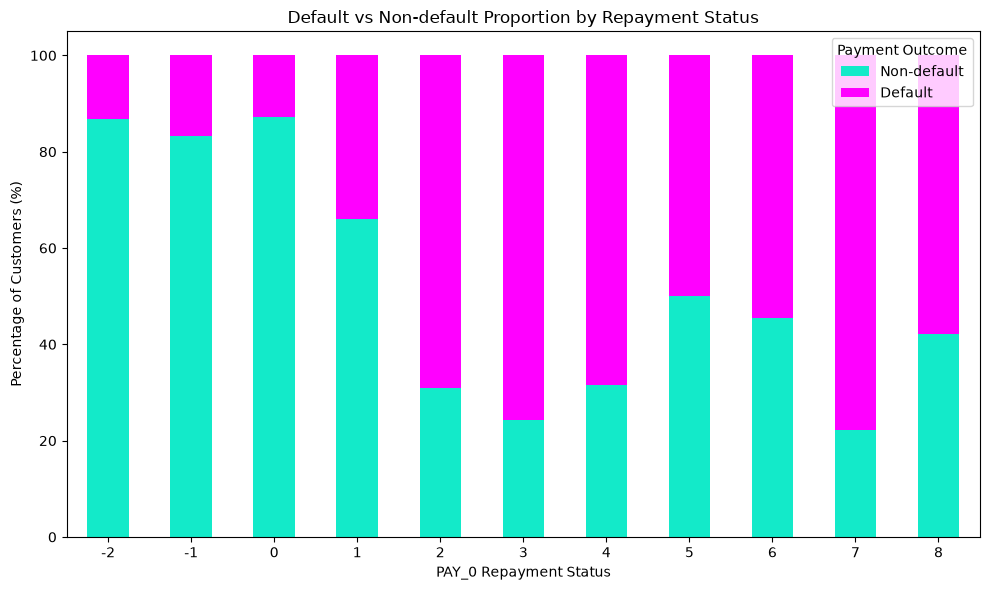

In [33]:
pay_default = pd.crosstab(
    df["PAY_0"],
    df["default payment next month"],
    normalize="index"
) * 100

pay_default = pay_default.reindex(columns=[0, 1], fill_value=0)

ax = pay_default.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#13EAC9","#FF00FF"]
)

plt.title("Default vs Non-default Proportion by Repayment Status")
plt.xlabel("PAY_0 Repayment Status")
plt.ylabel("Percentage of Customers (%)")
plt.xticks(rotation=0)

plt.legend(
    ["Non-default", "Default"],
    title="Payment Outcome"
)

plt.tight_layout()
plt.show()

In [34]:
comparison = df.groupby(
    "default payment next month"
).agg({
    "LIMIT_BAL": ["mean", "median"],
    "AGE": ["mean", "median"],
    "BILL_AMT1": ["mean", "median"],
    "PAY_AMT1": ["mean", "median"]
})

comparison

0                               LIMIT_BAL                  AGE         \
                                     mean    median       mean median   
default payment next month                                              
0                           178099.726074  150000.0  35.417266   34.0   
1                           130109.656420   90000.0  35.725738   34.0   

0                              BILL_AMT1              PAY_AMT1          
                                    mean   median         mean  median  
default payment next month                                              
0                           51994.227273  23119.5  6307.337357  2459.5  
1                           48509.162297  20185.0  3397.044153  1636.0

In [35]:
credit_summary = df.groupby(
    "default payment next month"
)["LIMIT_BAL"].agg(
    ["mean", "median", "std", "min", "max"]
)

credit_summary

,mean,median,std,min,max
default payment next month,,,,,
0,178099.726074,150000.0,131628.359660,10000,1000000
1,130109.656420,90000.0,115378.540571,10000,740000


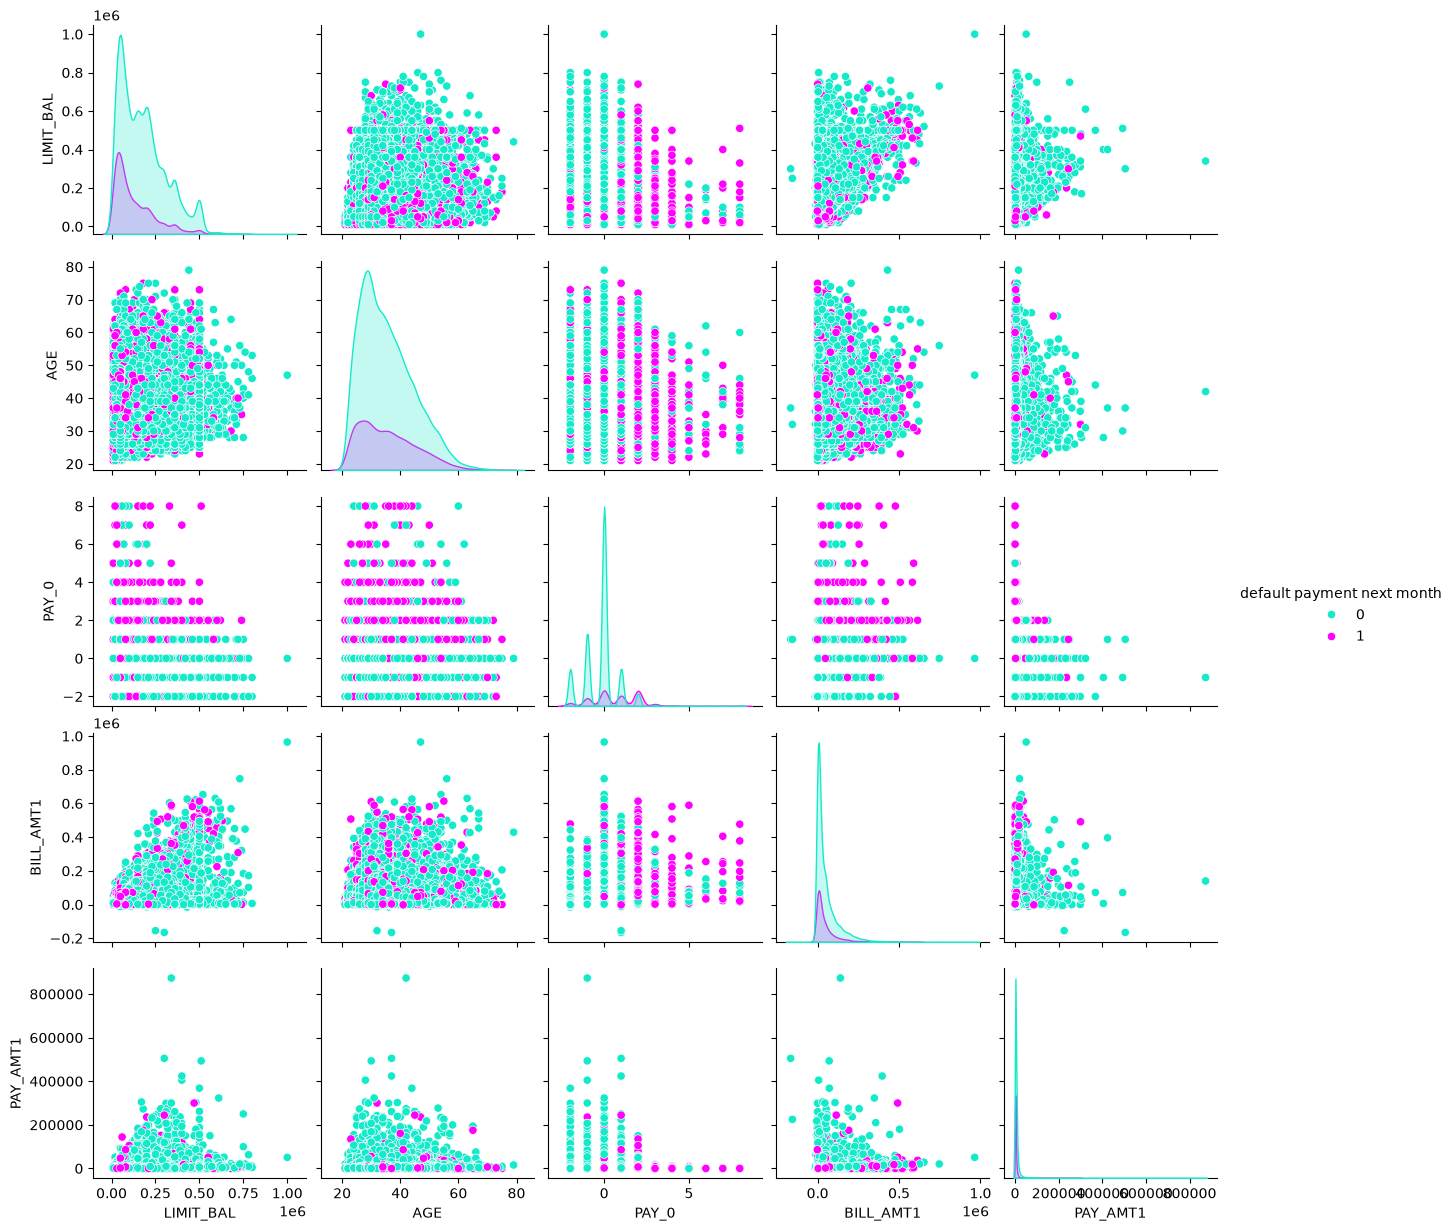

In [36]:
selected = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "BILL_AMT1",
    "PAY_AMT1",
    "default payment next month"
]

sns.pairplot(
    df[selected],
    hue="default payment next month",
    diag_kind="kde",
    palette={
        0: "#13EAC9",   # Aqua → non-default
        1: "#FF00FF"    # Pink → default
    }
)

plt.show()

### Q2 Explanation
##### The exploratory analysis compared customers who defaulted with those who did not in order to identify differences in their demographic characteristics, credit information, repayment behavior, bill amounts, and payment amounts.

##### One of the most important patterns is related to repayment status. Customers with more recent delayed-payment records tend to show higher default risk. The repayment-status variables, particularly the most recent repayment status, provide a strong indication of differences between default and non-default customers.

##### The analysis also examined variables such as credit limit, age, bill amounts, and payment amounts. These variables show differences between the two groups, although the amount of overlap between distributions means that no single variable can perfectly separate defaulters from non-defaulters.

##### Overall, the exploratory analysis suggests that recent repayment behavior is more clearly associated with default risk than demographic variables alone. This supports using multiple features together in the Logistic Regression model rather than relying on a single characteristic.

# Q3 - Which recent repayment behaviors appear most informative?

In [37]:
pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

default_rates = {}

for col in pay_cols:
    default_rates[col] = (
        df.groupby(col)["default payment next month"]
        .mean() * 100
    )

default_rates = pd.DataFrame(default_rates)

default_rates.round(1)

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,13.2,18.3,18.5,19.3,19.7,20.0
-1,16.8,16.0,15.6,15.9,16.2,17.0
0,12.8,15.9,17.5,18.3,18.9,18.8
1,33.9,17.9,25.0,50.0,NaN,NaN
2,69.1,55.6,51.6,52.3,54.2,50.7
3,75.8,61.7,57.5,61.1,63.5,64.1
4,68.4,50.5,57.9,66.7,60.7,63.3
5,50.0,60.0,57.1,51.4,58.8,53.8
6,54.5,75.0,60.9,40.0,75.0,73.7
7,77.8,60.0,81.5,82.8,82.8,82.6


### Step 2: Translating the codes
#### We don't want management to see: PAY_0 = 2
#### and have no idea what it means.
#### According to the dataset's coding, the repayment-status values include categories representing payment made on time, payment delays, and special statuses such as no consumption/no payment information.
#### For the delay categories, we can explicitly label them:

In [38]:
pay_labels = {
    -2: "No consumption",
    -1: "Paid duly",
     0: "Revolving credit",
     1: "1 month delay",
     2: "2 months delay",
     3: "3 months delay",
     4: "4 months delay",
     5: "5 months delay",
     6: "6 months delay",
     7: "7 months delay",
     8: "8+ months delay"
}

### Step 3:
#### Instead of six separate charts, let's calculate the default rate associated with repayment-delay severity.
#### For each PAY_*, calculate the default rate for the positive delay codes.

In [39]:
delay_rates = []

for col in pay_cols:

    temp = (
        df[df[col] >= 1]
        .groupby(col)["default payment next month"]
        .mean()
        .mul(100)
        .reset_index()
    )

    temp["month"] = col
    temp.columns = ["delay", "default_rate", "month"]

    delay_rates.append(temp)

delay_rates = pd.concat(delay_rates)

delay_rates

,delay,default_rate,month
0,1,33.947939,PAY_0
1,2,69.141357,PAY_0
2,3,75.776398,PAY_0
3,4,68.421053,PAY_0
4,5,50.000000,PAY_0
5,6,54.545455,PAY_0
6,7,77.777778,PAY_0
7,8,57.894737,PAY_0
0,1,17.857143,PAY_2
1,2,55.614973,PAY_2


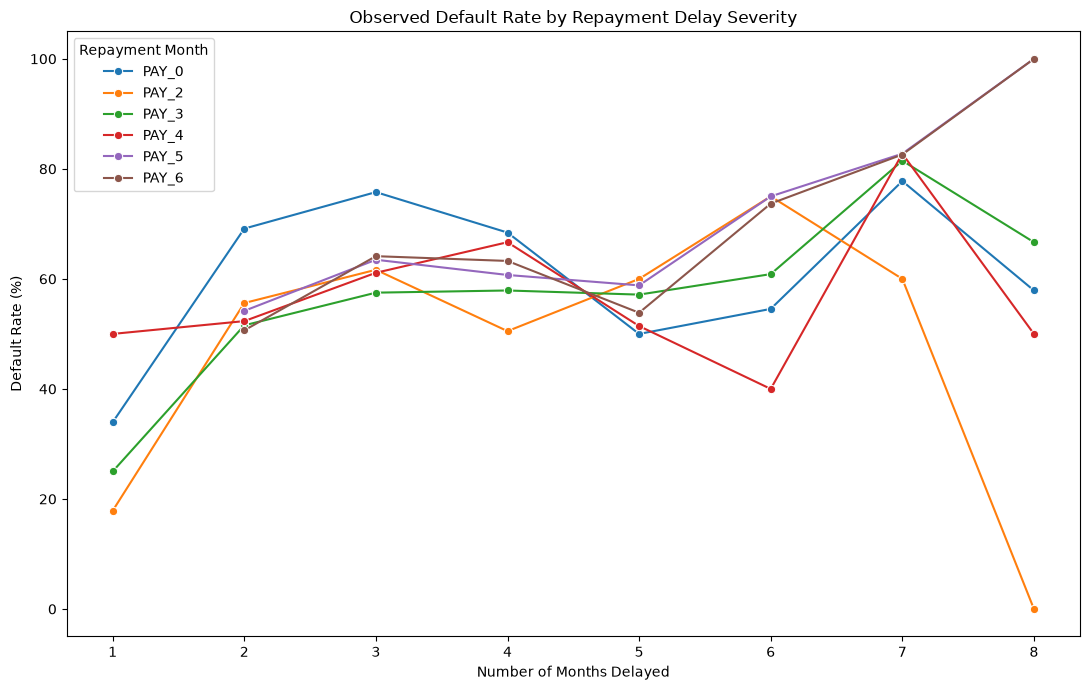

In [40]:
plt.figure(figsize=(11, 7))

sns.lineplot(
    data=delay_rates,
    x="delay",
    y="default_rate",
    hue="month",
    marker="o"
)

plt.title("Observed Default Rate by Repayment Delay Severity")
plt.xlabel("Number of Months Delayed")
plt.ylabel("Default Rate (%)")
plt.legend(title="Repayment Month")

plt.tight_layout()
plt.show()

In [41]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    phi2 = chi2 / n

    r, k = table.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )

In [42]:
association = {}

for col in pay_cols:
    association[col] = cramers_v(
        df[col],
        df["default payment next month"]
    )

association = pd.Series(association).sort_values(
    ascending=False
)

association

PAY_0    0.422538
PAY_2    0.339832
PAY_3    0.295102
PAY_4    0.278780
PAY_5    0.270109
PAY_6    0.250193
dtype: float64

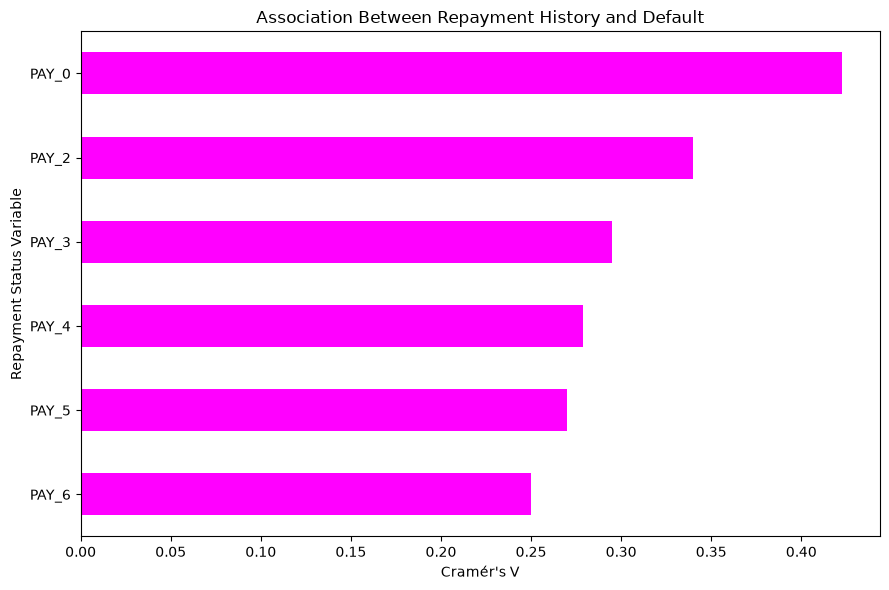

In [43]:
plt.figure(figsize=(9, 6))

association.sort_values().plot(
    kind="barh",
    color="#FF00FF"
)
plt.title(
    "Association Between Repayment History and Default"
)

plt.xlabel("Cramér's V")
plt.ylabel("Repayment Status Variable")

plt.tight_layout()
plt.show()

### Q3 Explanation
##### The repayment-status variables (PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, and PAY_6) describe customers' repayment behavior across recent months. These variables are particularly relevant because delayed payments indicate potential financial difficulty.

##### The exploratory analysis shows that recent repayment behavior is one of the most informative parts of the dataset for distinguishing default from non-default customers. In particular, PAY_0, which represents the most recent repayment status, shows a clear relationship with default risk. Higher repayment-delay values are associated with a greater likelihood of default.

##### This finding is also supported by the Logistic Regression model. The standardized coefficient for PAY_0 is +0.6538, indicating a positive association between higher values of the most recent repayment-status variable and predicted default risk, while holding the other model variables constant.

##### Therefore, recent repayment behavior provides an important signal for identifying customers who may be at higher risk of default. However, it should be considered together with the other available variables rather than treated as a causal explanation of default.

# Q4 - Can a simple baseline model predict default risk?

## Importing Recuired Libraries 

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

##### Our Target must be numeric so:

In [45]:
target = "default payment next month"
model_df = df.copy()
model_df[target] = pd.to_numeric(model_df[target], errors="coerce")

##### Using age_group instead of raw AGE:

In [46]:
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "age_group"
]

##### Converting categorical variables to string
##### &
##### Convert all remaining columns to numeric

In [47]:
for col in categorical_cols:
    model_df[col] = model_df[col].astype(str)

numeric_candidate_cols = [
    col for col in model_df.columns
    if col not in categorical_cols + [target]
]

for col in numeric_candidate_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

#### Features & Target:

In [48]:
X = model_df.drop(columns=[target])
y = model_df[target].astype(int)

#### Numeric Columns:

In [49]:
numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

#### Train / Test Split:

In [50]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 21000
Validation samples: 4500
Test samples: 4500


#### Preprocessing:

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

#### Logistic Regression Baseline:

In [52]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "logistic",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

#### Fit ONLY on Training Data:

In [53]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['ID','LIMIT_BAL','SEX',...,'PAY_AMT5','PAY_AMT6','age_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

#### Predictions:

In [54]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]
y_test_prob = logistic_model.predict_proba(X_test)[:, 1]

In [55]:
# Default threshold = 0.50
y_test_pred = (y_test_prob >= 0.50).astype(int)

In [56]:
print("\nLogistic Regression training completed.")
print()
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")


Logistic Regression training completed.

Training samples:   21000
Validation samples: 4500
Test samples:       4500


### Explanation for Q4
##### A Logistic Regression model was developed as the baseline classifier. The dataset was divided into training, validation, and test sets using stratified sampling to preserve the proportion of default and non-default customers. Numeric variables were standardized, while categorical variables were one-hot encoded. All preprocessing steps were included in a pipeline and fitted only on the training data to prevent data leakage. A fixed random state was used to make the workflow reproducible.

### Q5 - Evaluate the model

In [57]:
cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

print("\n================ MODEL EVALUATION ================")

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nPrecision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


================ MODEL EVALUATION ================

Confusion Matrix:
[[3405   99]
 [ 757  239]]

TN: 3405
FP: 99
FN: 757
TP: 239

Precision: 0.7071
Recall: 0.24
F1-score: 0.3583
ROC-AUC: 0.7188
PR-AUC: 0.4948

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      3504
           1       0.71      0.24      0.36       996

    accuracy                           0.81      4500
   macro avg       0.76      0.61      0.62      4500
weighted avg       0.79      0.81      0.77      4500



### Confusion matrix plot

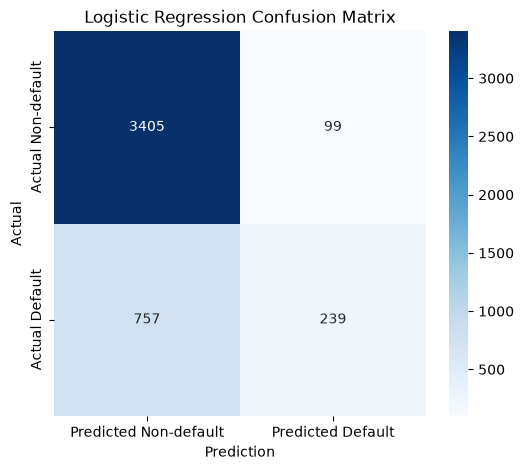

In [58]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-default", "Predicted Default"],
    yticklabels=["Actual Non-default", "Actual Default"]
)
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### ROC curve

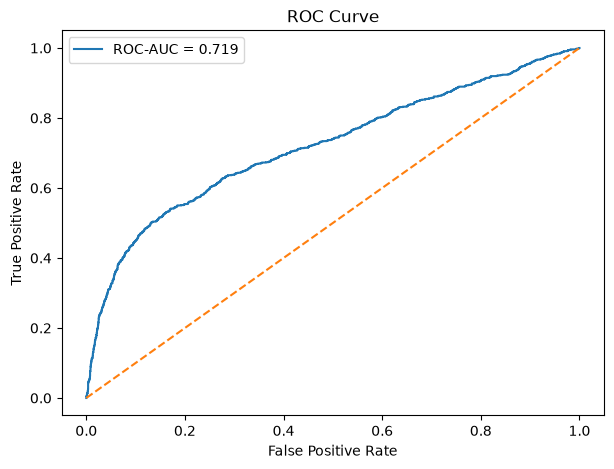

In [59]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Precision-Recall curve

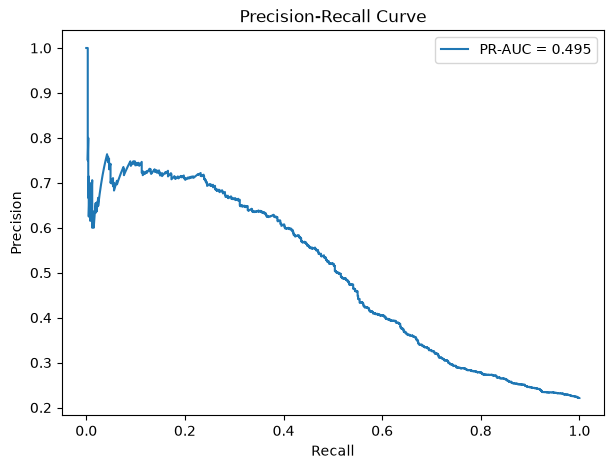

In [60]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Explanation for Q5

##### The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC. The confusion matrix shows the numbers of correctly and incorrectly classified customers. Accuracy alone is insufficient because the dataset is imbalanced: approximately 78% of customers are non-default and 22% are default. Therefore, a model could achieve relatively high accuracy by mostly predicting the majority class while still failing to identify many customers who actually default. Precision measures how many predicted defaults were correct, while Recall measures how many actual defaults were successfully identified. F1-score provides a balance between Precision and Recall, while ROC-AUC and PR-AUC evaluate model discrimination across different thresholds.

## Q6 - False Negatives vs False Positives

### False Negative (FN) = 757
##### Customer actually defaults → model predicts non-default.

### False Positive (FP) = 99
##### Customer does not default → model predicts default.
#### For credit risk, FN can potentially be more costly because the company fails to identify a risky customer.

### Explanation for Q6
##### False negatives occur when a customer who actually defaults is classified as non-default. In this credit-risk scenario, false negatives can be particularly costly because the company may fail to identify a customer who requires additional risk management. False positives occur when a non-defaulting customer is incorrectly classified as a defaulter, potentially resulting in unnecessary reviews or restrictions. Therefore, the choice of classification threshold should reflect the business cost of these two types of errors. If missing defaulters is considered more costly, greater emphasis should be placed on Recall, while still monitoring Precision to avoid excessive false positives.

## Q7 - Create Low / Medium / High Risk Groups

In [61]:
thresholds = [0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:

    val_pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, val_pred),
        "Recall": recall_score(y_val, val_pred),
        "F1": f1_score(y_val, val_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.2,0.323019,0.692462,0.440537
1,0.3,0.574684,0.456281,0.508683
2,0.4,0.628227,0.366834,0.463198
3,0.5,0.708455,0.244221,0.363229


In [62]:
risk_output = pd.DataFrame({
    "default_probability": y_test_prob,
    "actual_default": y_test.values
})

risk_output["risk_group"] = pd.cut(
    risk_output["default_probability"],
    bins=[-np.inf, 0.20, 0.50, np.inf],
    labels=["Low", "Medium", "High"]
)

risk_summary = (
    risk_output
    .groupby("risk_group", observed=False)
    .agg(
        customer_count=("actual_default", "size"),
        default_count=("actual_default", "sum"),
        default_rate=("actual_default", "mean")
    )
)

risk_summary["default_rate"] *= 100

risk_summary

,customer_count,default_count,default_rate
risk_group,,,
Low,2388,304,12.730318
Medium,1774,453,25.535513
High,338,239,70.710059


#### Saving to CSV

In [67]:
risk_output.to_csv(
    "risk_groups.csv",
    index=False
)

print(risk_output.head())

   default_probability  actual_default risk_group
0             0.209280               0     Medium
1             0.191953               0        Low
2             0.492632               1     Medium
3             0.248314               0     Medium
4             0.571009               0       High


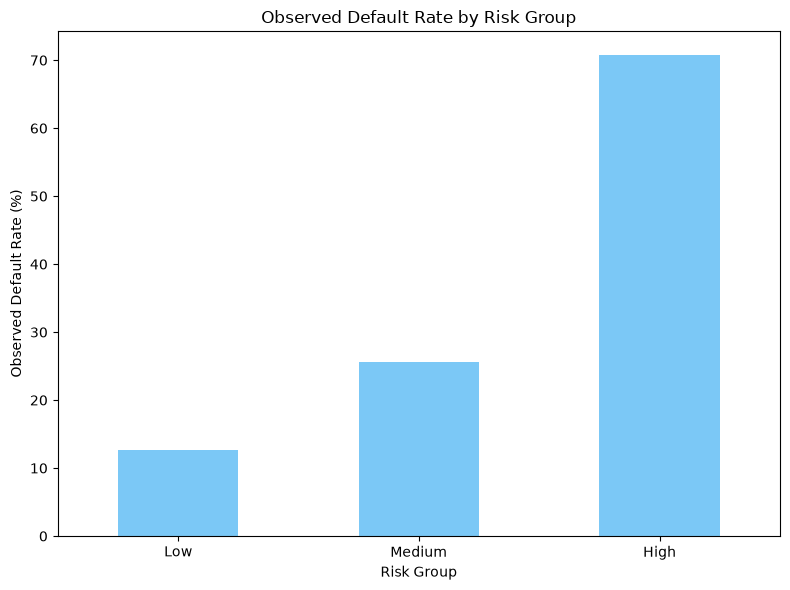

In [63]:
plt.figure(figsize=(8, 6))

risk_summary["default_rate"].plot(kind="bar", color="#7BC8F6")

plt.title("Observed Default Rate by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Observed Default Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Explanation for Q7
##### The Logistic Regression model produces a probability of default for each customer rather than only a binary prediction. These probabilities were converted into three risk segments using predefined business-review cutoffs: Low Risk for probabilities below 20%, Medium Risk for probabilities from 20% to 50%, and High Risk for probabilities above 50%. The validation set was used to examine how different thresholds affect Precision and Recall, while the final risk segmentation was applied to the test set using the predefined cutoffs. The resulting groups provide a more actionable representation of customer risk than a simple default/non-default classification.

## Q8 - Explain the Logistic Regression coefficients

In [64]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["logistic"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = (
    coef_df
    .sort_values("abs_coefficient", ascending=False)
)

coef_df.head(15)

,feature,coefficient,abs_coefficient
26,categorical__EDUCATION_4,-0.962623,0.962623
3,numeric__PAY_0,0.653804,0.653804
22,categorical__SEX_2,-0.426990,0.426990
28,categorical__MARRIAGE_2,-0.357679,0.357679
9,numeric__BILL_AMT1,-0.326868,0.326868
21,categorical__SEX_1,-0.312217,0.312217
16,numeric__PAY_AMT2,-0.254467,0.254467
29,categorical__MARRIAGE_3,-0.224227,0.224227
31,categorical__age_group_26-30,-0.221160,0.221160
23,categorical__EDUCATION_1,0.171777,0.171777


### Plot the strongest coefficients:

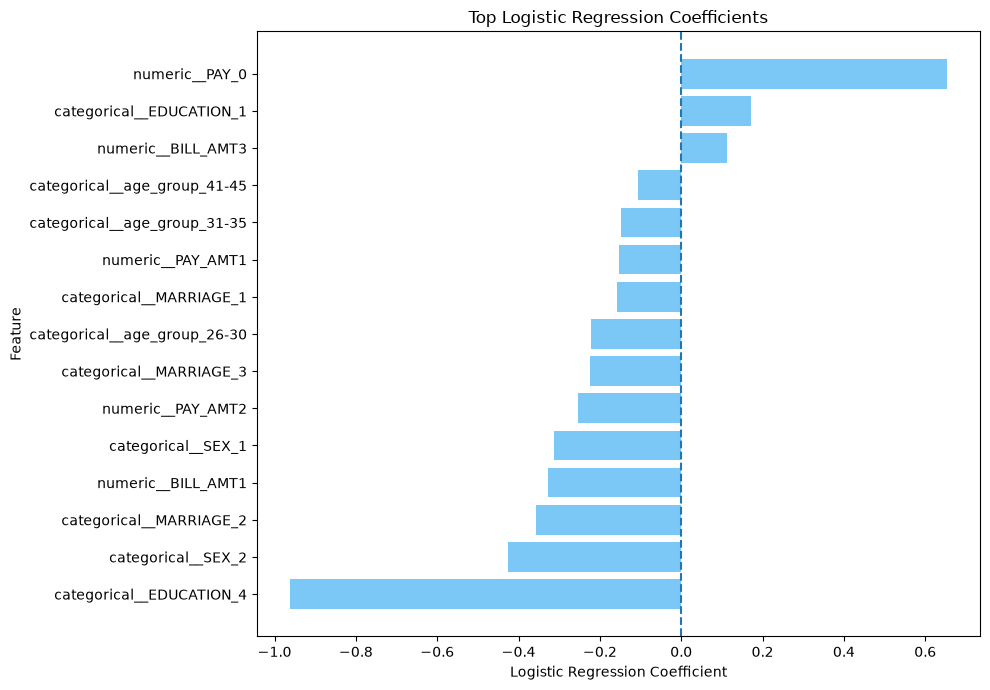

In [65]:
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_coef["feature"],
    top_coef["coefficient"],
    color="#7BC8F6"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

#### Positive coefficient : associated with higher predicted default probability.
#### Negative coefficient : associated with lower predicted default probability.
#### Larger absolute value : stronger influence within the model's linear structure.

### Explanation for Q8
##### Logistic Regression coefficients were used as a simple explainability method. A positive coefficient indicates that, holding other variables constant, the corresponding feature is associated with higher predicted default risk, while a negative coefficient indicates lower predicted risk. Numeric variables were standardized, which makes their coefficient magnitudes more comparable across numeric predictors. However, the coefficients represent statistical associations within the model and should not be interpreted as evidence of causation. In addition, correlated predictors can affect the stability and interpretation of individual coefficients.

## Q9 - Compare different classification thresholds

In [66]:
threshold_results = []

for threshold in [0.30, 0.50]:

    predictions = (
        y_test_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.3,0.554348,0.460843,0.503289,369,537
1,0.5,0.707101,0.239960,0.358321,99,757


### Explanation for Q9
##### Changing the classification threshold changes the balance between Precision and Recall. A lower threshold such as 0.30 classifies more customers as potential defaulters, which generally increases Recall because more actual defaulters are identified. However, this can also increase false positives and reduce Precision. A higher threshold such as 0.50 is more conservative when assigning the default class, which can reduce false positives but may miss more actual defaulters. Therefore, the appropriate threshold depends on the relative business costs of false negatives and false positives.

## Q10 - Management Summary

##### The objective of this project was to develop a machine learning approach for identifying customers who are at risk of defaulting on their next credit-card payment and to translate the model output into actionable risk segments.

##### A Logistic Regression model was developed as a baseline because it provides both predictive probabilities and relatively straightforward interpretability. The dataset was divided into training, validation, and test sets using stratified sampling. Numeric variables were standardized and categorical variables were one-hot encoded within a preprocessing pipeline to avoid data leakage.

##### Model evaluation showed that Accuracy alone is not sufficient for this problem because the dataset contains substantially more non-default than default observations. Therefore, Precision, Recall, F1-score, ROC-AUC, and PR-AUC were considered alongside the confusion matrix. In particular, Recall is important because failing to identify a customer who will default may represent a significant business risk.

##### The predicted probabilities were also converted into Low, Medium, and High risk groups using predefined probability thresholds. This provides a more useful output for management than a simple binary classification because customers can be prioritized according to their estimated level of risk.

##### The model should be viewed as a decision-support tool rather than a replacement for human judgment. Before deployment, the model would require validation on more recent data, probability calibration, monitoring for changes in customer behavior and data distributions, evaluation across relevant customer subgroups, and a business-based assessment of the costs associated with false positives and false negatives.

##### Finally, the model identifies statistical associations rather than causal relationships. Its predictions should therefore be interpreted as estimates of default risk rather than explanations of why an individual customer will default.